# Bayesian inversion of diffusivity in Poisson equation

Run in **`neuralopv2`**. True forward model by default; set `load_surrogate=True` for neural operators.

**Prerequisite:** Regenerate `Results/ground_truth/data.npz` via `Generate_GroundTruth.ipynb` on the FEniCSx mesh.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import pickle
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from dolfinx import mesh
from dolfinx.fem import functionspace
from dolfinx.mesh import CellType
from mpi4py import MPI
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.interpolate import griddata

NOTEBOOK_DIR = os.getcwd()
ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..', '..', '..'))
POISSON_DIR = os.path.join(ROOT, "survey_work/problems/poisson")

sys.path.insert(0, os.path.join(ROOT, "src/plotting"))
sys.path.insert(0, os.path.join(ROOT, "src/data"))
sys.path.insert(0, os.path.join(ROOT, "src/prior"))
sys.path.insert(0, os.path.join(ROOT, "src/mcmc"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/deeponet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/pcanet"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/fno"))
sys.path.insert(0, os.path.join(ROOT, "src/nn/mlp"))
sys.path.insert(0, POISSON_DIR)

from compute_sample_errors import compute_sample_errors
from field_plot import field_plot
from load_data_and_deeponet import load_data_and_deeponet
from load_data_and_fno import load_data_and_fno
from load_data_and_pcanet import load_data_and_pcanet
from mcmc import MCMC
from mcmc_plot_fields import mcmc_plot_fields, mcmc_plot_fields_base
from plot_curve import plot_curve
from plot_mix_collection import plot_collection
from point_plot import point_plot
from poissonModel import PoissonModel
from priorSampler import PriorSampler
from surrogateModel import SurrogateModel, SurrogateModelFNO

plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

In [2]:
model_path = POISSON_DIR
results_dir = os.path.join(NOTEBOOK_DIR, "Results")
os.makedirs(results_dir, exist_ok=True)

In [3]:
run_small_test = True # small number of samples and tests true and DeepONet surrogate model

# Create PoissonModel

In [4]:
prior_ac = 0.005
prior_cc = 0.2
prior_logn_scale = 1
prior_logn_translate = 0.0
nx, ny = 50, 50
fe_order = 1

domain = mesh.create_unit_square(MPI.COMM_WORLD, nx, ny, cell_type=CellType.triangle)
Vm = functionspace(domain, ("Lagrange", fe_order))
Vu = Vm

prior_sampler = PriorSampler(Vm, prior_ac, prior_cc, seed)
model = PoissonModel(Vm, Vu, prior_sampler, prior_logn_scale, prior_logn_translate, seed)
nodes = model.m_nodes


# Load Neural Operators

In [5]:
surrogate_models = None
load_surrogate = True

if run_small_test:
    load_surrogate = True

In [6]:
if load_surrogate:
    def load_deeponet():
        data_path = model_path + '/data/' + 'Poisson_samples.npz'
        nn_path = model_path + '/DeepONet/Results/model.pkl'
        data, nn = load_data_and_deeponet(data_path, nn_path)
        nn_surrogate = SurrogateModel(model, nn, data)
        print('nn_data: ', data)
        print('nn_model: ', nn)

        return nn_surrogate

    deeponet = load_deeponet()

nn_data:  <dataMethods.DataProcessor object at 0x3410b0530>
nn_model:  DeepONet(
  (branch_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2601, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=100, bias=True)
    )
  )
  (trunk_net): MLP(
    (layers): ModuleList(
      (0): Linear(in_features=2, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=64, bias=True)
      (2): Linear(in_features=64, out_features=100, bias=True)
    )
  )
)


In [7]:
if load_surrogate and not run_small_test:
    def load_pcanet():
        data_path = model_path + '/data/' + 'Poisson_samples.npz'
        nn_path = model_path + '/PCANet/Results/model.pkl'
        data, nn = load_data_and_pcanet(data_path, nn_path)
        nn_surrogate = SurrogateModel(model, nn, data)
        print('nn_data: ', data)
        print('nn_model: ', nn)

        return nn_surrogate

    pcanet = load_pcanet()  

In [8]:
if load_surrogate and not run_small_test:
    def load_fno():
        data_path = model_path + '/data/' + 'Poisson_FNO_samples.npz'
        nn_path = model_path + '/FNO/Results/model.pkl'
        data, nn = load_data_and_fno(data_path, nn_path)
        # get some additional data for FNO
        trunk_nodes = deeponet.data.X_trunk
        grid_x = data.grid_x_test[0, :, :, 0]
        grid_y = data.grid_y_test[0, :, :, 0]
        nn_surrogate = SurrogateModelFNO(model, nn, data, trunk_nodes, grid_x, grid_y, u_comps = 1)
        print('nn_data: ', data)
        print('nn_model: ', nn)

        return nn_surrogate

    fno = load_fno()

In [9]:
if load_surrogate and not run_small_test:
    surrogate_models = {'DeepONet': deeponet, 'PCANet': pcanet, 'FNO': fno}
else:
    surrogate_models = {'DeepONet': deeponet}


In [10]:
if load_surrogate:
    t1 = time.time()
    w1 = model.samplePrior(transform_m = False)
    w2 = w1.copy()
    t2 = time.time()
    print('Time to sample m: {:.3f}'.format(t2 - t1))

    # model solver
    t1 = time.time()
    m = model.transform_gaussian_pointwise(w1)
    u_model = model.solveFwd(u = None, m = m, transform_m = False)
    t2 = time.time()
    print('Time to solve Poisson model forward: {:.3f}'.format(t2 - t1))

    # neural operators
    sm_use = surrogate_models.keys()
    for sm in sm_use:
        t1 = time.time()
        u_sm = surrogate_models[sm].solveFwd(w2)
        t2 = time.time()
        u_err = np.linalg.norm(u_model - u_sm) / np.linalg.norm(u_model)
        print('Time to solve {} forward: {:.3f}, err: {:.3e}'.format(surrogate_models[sm].model_type, t2 - t1, u_err))

Time to sample m: 0.001
Time to solve Poisson model forward: 0.004
Time to solve DeepONet forward: 0.003, err: 1.489e-02


# Load ground truth

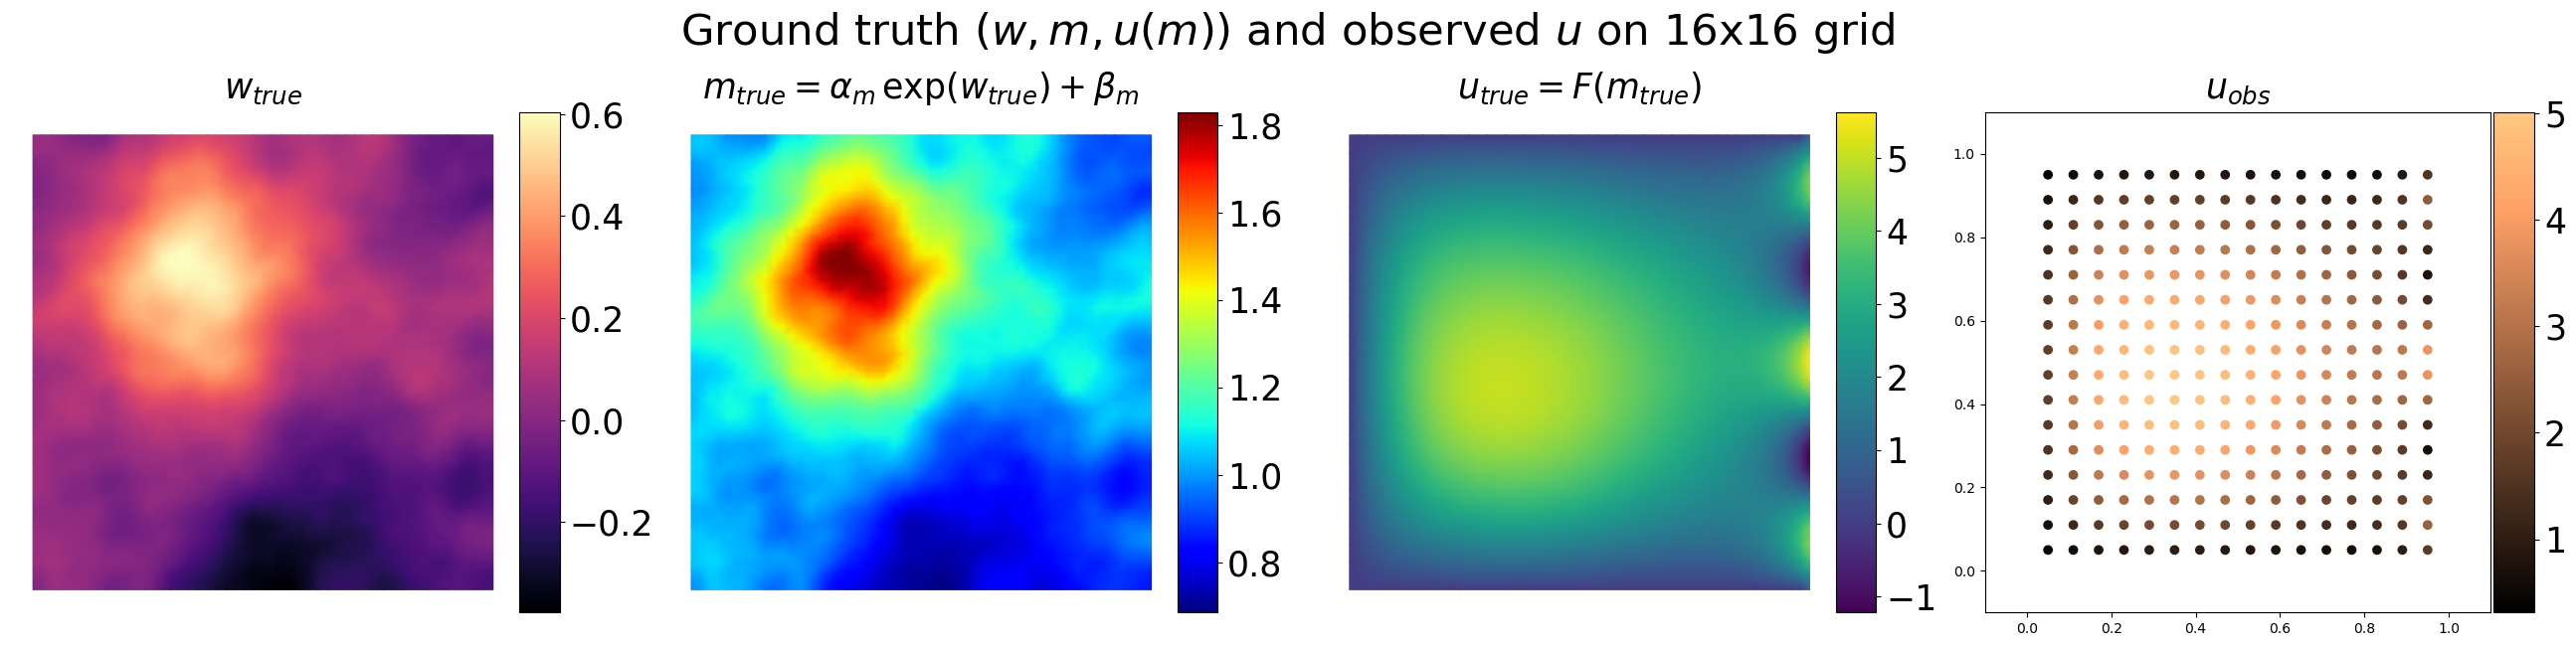

In [11]:
ground_truth_data = np.load(os.path.join(results_dir, "ground_truth/data.npz"))
num_grid_x, num_grid_y = ground_truth_data["num_grid_x"], ground_truth_data["num_grid_y"]
w_true = ground_truth_data["w_true"]
m_true = ground_truth_data["m_true"]
u_true = ground_truth_data["u_true"]
x_obs = ground_truth_data["x_obs"]
u_obs = ground_truth_data["u_obs"]

nodes = model.m_nodes

rows, cols = 1, 4
fig, axs = plt.subplots(rows, cols, figsize=(26, 6))
axs = np.atleast_1d(axs).reshape(rows, cols)

uvec = [[w_true, m_true, u_true]]
title_vec = [[
    r"$w_{true}$",
    r"$m_{true} = \alpha_m\, \exp(w_{true}) + \beta_m$",
    r"$u_{true} = F(m_{true})$",
    r"$u_{obs}$",
]]
cmap_vec = [["magma", "jet", "viridis", "copper"]]
sup_title = r"Ground truth $(w, m, u(m))$ and observed $u$ on {}x{} grid".format(
    num_grid_x, num_grid_y
)
fs = 25
y_sup_title = 1.075
savefilename = os.path.join(results_dir, "true_and_obs_w_m_u.png")

for i in range(rows):
    for j in range(cols):
        if j == cols - 1:
            axs[i, j].set_xlim([-0.1, 1.1])
            axs[i, j].set_ylim([-0.1, 1.1])
        if j < cols - 1:
            cbar = field_plot(axs[i, j], uvec[i][j], nodes, cmap=cmap_vec[i][j])
        else:
            cbar = point_plot(axs[i, j], u_obs, x_obs, cmap=cmap_vec[i][j])
        divider = make_axes_locatable(axs[i, j])
        cax = divider.append_axes("right", size="8%", pad=0.03)
        cax.tick_params(labelsize=fs)
        fig.colorbar(cbar, cax=cax, orientation="vertical")
        if j < cols - 1:
            axs[i, j].axis("off")
        if title_vec is not None:
            axs[i, j].set_title(title_vec[i][j], fontsize=fs, pad=10)

fig.tight_layout()
fig.suptitle(sup_title, fontsize=1.25 * fs, y=y_sup_title)
fig.savefig(savefilename, bbox_inches="tight")
plt.show()


## Compute noise

In [12]:
u_obs_mean, u_obs_std = np.mean(u_obs), np.std(u_obs)
sigma_noise = 0.05 * u_obs_mean
print('u_obs_mean = {:.3e}, u_obs_std = {:.3e}, sigma_noise: {:.3e}'.format(u_obs_mean, u_obs_std, sigma_noise))

u_obs_mean = 2.645e+00, u_obs_std = 1.267e+00, sigma_noise: 1.323e-01


# MCMC setup

In [ ]:
pcn_beta = 0.2
surrogate_to_use = None

mcmc = MCMC(
    model,
    prior_sampler,
    ground_truth_data,
    sigma_noise=sigma_noise,
    pcn_beta=pcn_beta,
    surrogate_to_use=surrogate_to_use,
    surrogate_models=surrogate_models,
    seed=seed
)

mcmc.pp_params = {
    "curve_plot": {"fs": 12, "lw": 3, "figsize": (4, 3)},
    "field_plot": {
        "fs": 10,
        "y_sup_title": 1.025,
        "figsize": (8, 6),
        "ttl_pad": 5,
        "title_x": [0.6, 0.65, 0.65, 0.6],
        "u_vec_plot": True,
    },
}

In [ ]:
n_samples = 10000
n_burnin = 500
print_every = 500
display_plot_every = 5 * print_every

if run_small_test:
    n_samples = 100
    n_burnin = 20
    print_every = 5
    display_plot_every = 2 * print_every

mcmc.surrogate_to_use = None

savepath_prefix = "mcmc_" if not run_small_test else "test_mcmc_"
savepath_base = os.path.join(results_dir, f"{savepath_prefix}n_samples_{n_samples:d}_n_burnin_{n_burnin:d}_pcn_beta_{pcn_beta:.3f}_sigma_{sigma_noise:.3e}")

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, f"true_model")

os.makedirs(savepath, exist_ok=True)
savefilename = "tracer"


# MCMC with true model

In [ ]:
run_mcmc = True  

if run_mcmc or run_small_test:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        init_tracer=True,
        savepath=savepath + os.sep,
    )


### Load tracer and plot

In [ ]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.200_sigma_1.393e-01"
saved_results = savepath

if run_small_test:
        saved_results = savepath

load_tracer = pickle.load(open(saved_results + '/tracer' + '.pkl', 'rb'))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "title_x": [0.6, 0.65, 0.65, 0.6],        
    },
}

pp_params = mcmc_pp_params['curve_plot']
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)


w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)

# MCMC with surrogate: DeepONet

--------------------------------------------------
MCMC started with 100 samples and 20 burnin
PCN beta: 2.000e-01, sigma_noise: 1.323e-01
Model used for solving the forward problem: DeepONet
Tracer save path: surrogate_DeepONet
Tracer save filename: tracer
--------------------------------------------------
initializing the current state. Initial cost: 1.535e+03
--------------------------------------------------
Burnin:    0, Cost: 1.535e+03
--------------------------------------------------
--------------------------------------------------
Burnin:    5, Cost: 1.006e+03
--------------------------------------------------
--------------------------------------------------
Burnin:   10, Cost: 6.912e+02
--------------------------------------------------
--------------------------------------------------
Burnin:   15, Cost: 1.395e+02
--------------------------------------------------
--------------------------------------------------
Sample:   20, Accepted samples:    0, Acceptance Rate: 0

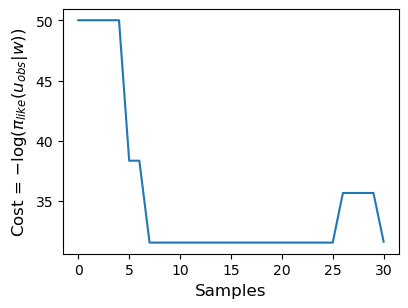

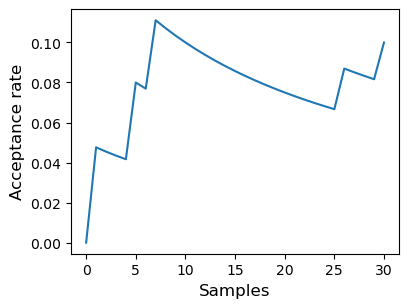

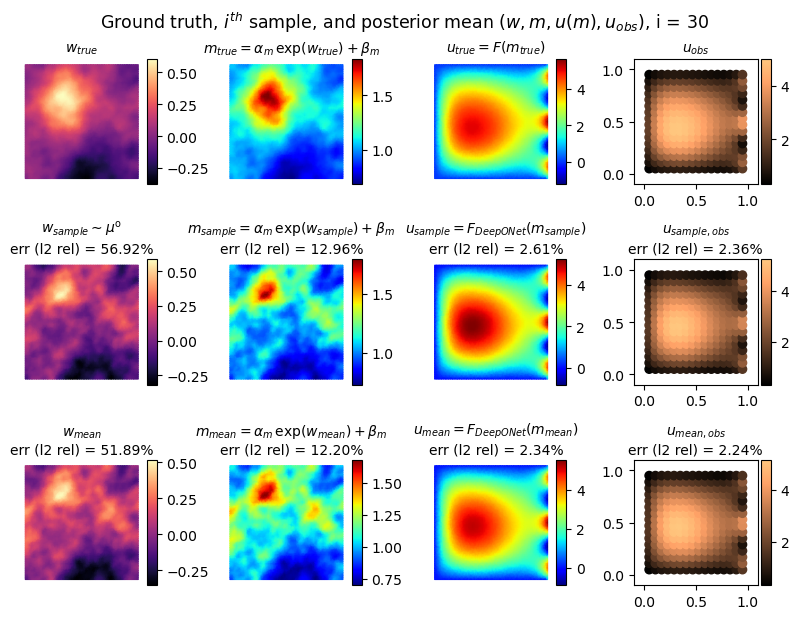

--------------------------------------------------
Sample:   55, Accepted samples:    5, Acceptance Rate: 9.091e-02, Cost mean: 3.537e+01. 
Tracing 5 samples took 3.523e+00s
Error (%) in w: ||w - w_mean|| = 5.288e+01, ||w - w_sample|| = 5.692e+01
Error (%) in m: ||m - m_mean|| = 1.237e+01, ||m - m_sample|| = 1.296e+01
Error (%) in u: ||u - u_mean|| = 2.357e+00, ||u - u_sample|| = 2.612e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.230e+00, ||u_obs - u_obs_sample|| = 2.359e+00
--------------------------------------------------
--------------------------------------------------
Sample:   60, Accepted samples:    5, Acceptance Rate: 8.333e-02, Cost mean: 3.537e+01. 
Tracing 5 samples took 2.119e+00s
Error (%) in w: ||w - w_mean|| = 5.288e+01, ||w - w_sample|| = 5.692e+01
Error (%) in m: ||m - m_mean|| = 1.237e+01, ||m - m_sample|| = 1.296e+01
Error (%) in u: ||u - u_mean|| = 2.357e+00, ||u - u_sample|| = 2.612e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.230e+00, ||u_obs - u_ob

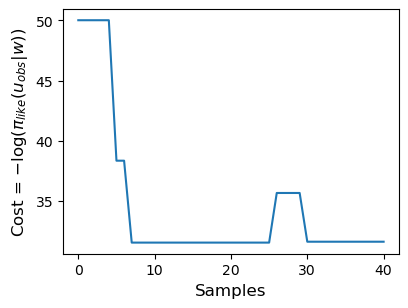

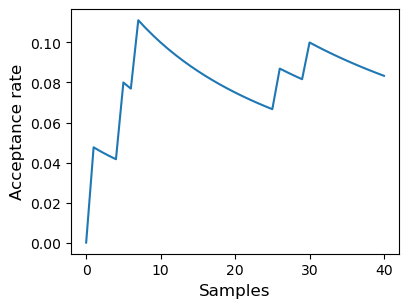

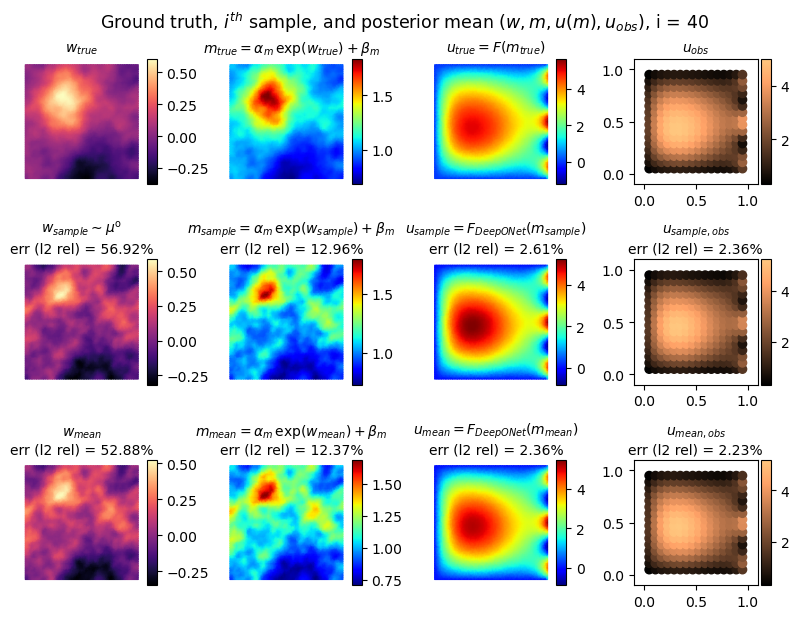

--------------------------------------------------
Sample:   65, Accepted samples:    5, Acceptance Rate: 7.692e-02, Cost mean: 3.447e+01. 
Tracing 5 samples took 4.146e+00s
Error (%) in w: ||w - w_mean|| = 5.339e+01, ||w - w_sample|| = 5.692e+01
Error (%) in m: ||m - m_mean|| = 1.243e+01, ||m - m_sample|| = 1.296e+01
Error (%) in u: ||u - u_mean|| = 2.362e+00, ||u - u_sample|| = 2.612e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.211e+00, ||u_obs - u_obs_sample|| = 2.359e+00
--------------------------------------------------
--------------------------------------------------
Sample:   70, Accepted samples:    5, Acceptance Rate: 7.143e-02, Cost mean: 3.447e+01. 
Tracing 5 samples took 2.252e+00s
Error (%) in w: ||w - w_mean|| = 5.339e+01, ||w - w_sample|| = 5.692e+01
Error (%) in m: ||m - m_mean|| = 1.243e+01, ||m - m_sample|| = 1.296e+01
Error (%) in u: ||u - u_mean|| = 2.362e+00, ||u - u_sample|| = 2.612e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.211e+00, ||u_obs - u_ob

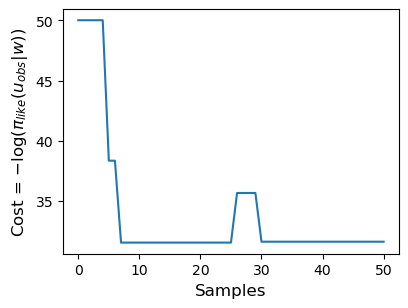

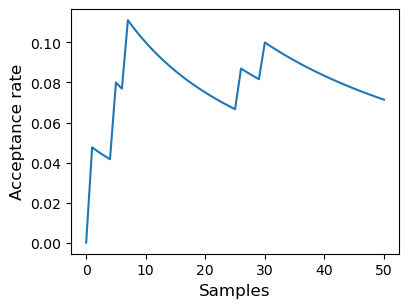

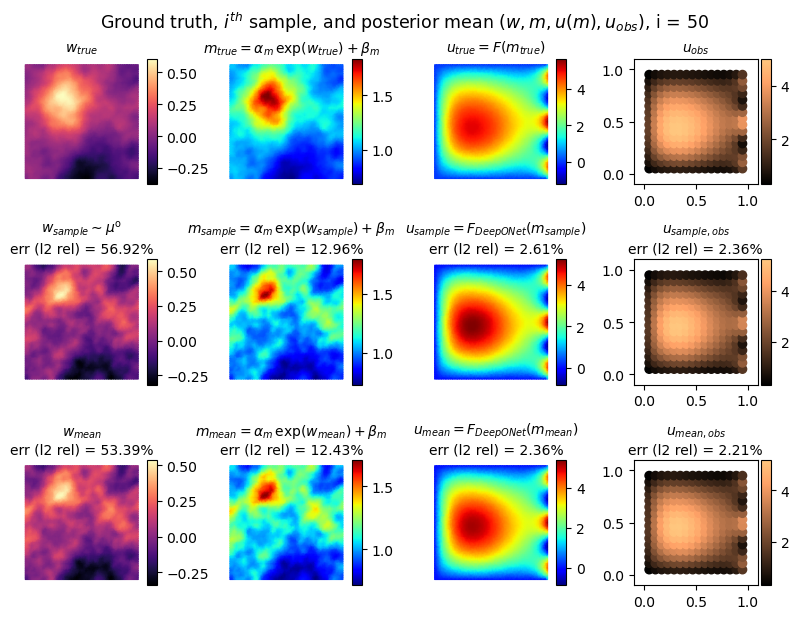

--------------------------------------------------
Sample:   75, Accepted samples:    5, Acceptance Rate: 6.667e-02, Cost mean: 3.392e+01. 
Tracing 5 samples took 3.860e+00s
Error (%) in w: ||w - w_mean|| = 5.385e+01, ||w - w_sample|| = 5.692e+01
Error (%) in m: ||m - m_mean|| = 1.249e+01, ||m - m_sample|| = 1.296e+01
Error (%) in u: ||u - u_mean|| = 2.383e+00, ||u - u_sample|| = 2.612e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.215e+00, ||u_obs - u_obs_sample|| = 2.359e+00
--------------------------------------------------
--------------------------------------------------
Sample:   80, Accepted samples:    6, Acceptance Rate: 7.500e-02, Cost mean: 3.392e+01. 
Tracing 5 samples took 2.236e+00s
Error (%) in w: ||w - w_mean|| = 5.385e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.249e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.383e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.215e+00, ||u_obs - u_ob

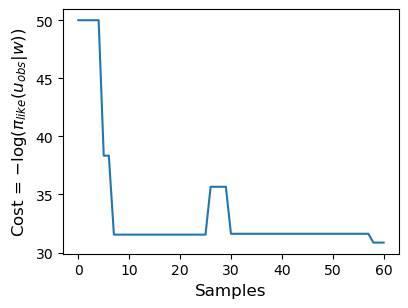

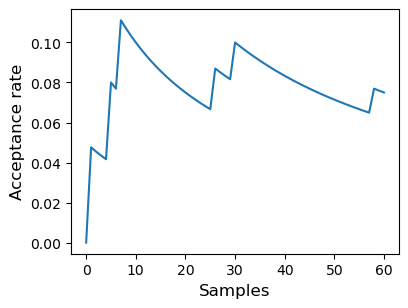

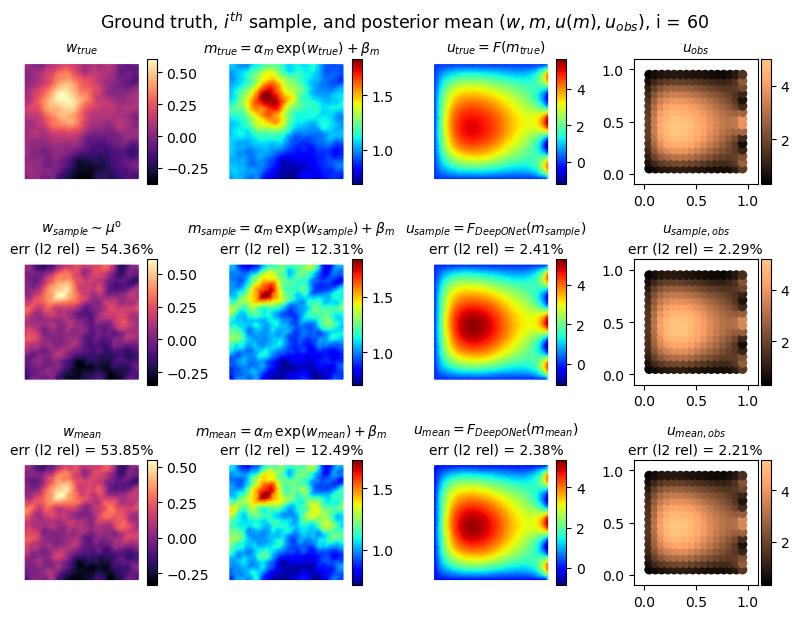

--------------------------------------------------
Sample:   85, Accepted samples:    6, Acceptance Rate: 7.059e-02, Cost mean: 3.350e+01. 
Tracing 5 samples took 3.881e+00s
Error (%) in w: ||w - w_mean|| = 5.389e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.247e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.386e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.214e+00, ||u_obs - u_obs_sample|| = 2.287e+00
--------------------------------------------------
--------------------------------------------------
Sample:   90, Accepted samples:    6, Acceptance Rate: 6.667e-02, Cost mean: 3.350e+01. 
Tracing 5 samples took 2.082e+00s
Error (%) in w: ||w - w_mean|| = 5.389e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.247e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.386e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.214e+00, ||u_obs - u_ob

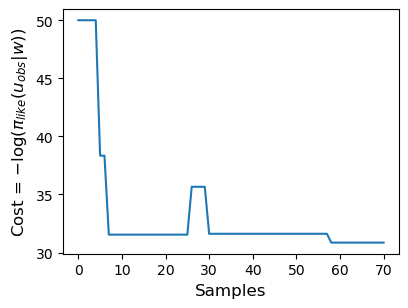

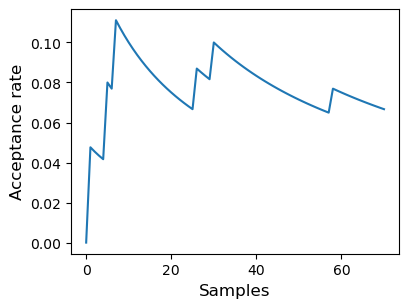

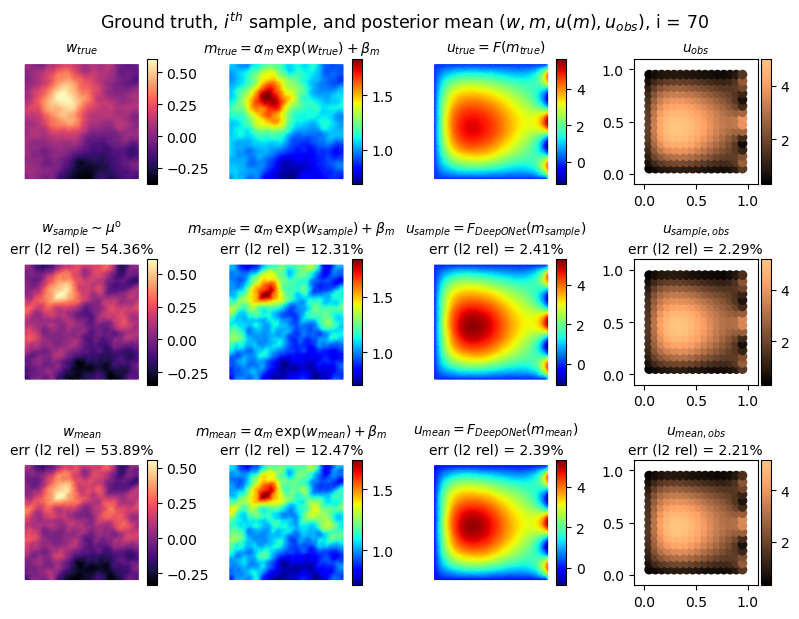

--------------------------------------------------
Sample:   95, Accepted samples:    6, Acceptance Rate: 6.316e-02, Cost mean: 3.313e+01. 
Tracing 5 samples took 3.946e+00s
Error (%) in w: ||w - w_mean|| = 5.358e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.238e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.368e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.205e+00, ||u_obs - u_obs_sample|| = 2.287e+00
--------------------------------------------------
--------------------------------------------------
Sample:  100, Accepted samples:    6, Acceptance Rate: 6.000e-02, Cost mean: 3.313e+01. 
Tracing 5 samples took 2.406e+00s
Error (%) in w: ||w - w_mean|| = 5.358e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.238e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.368e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.205e+00, ||u_obs - u_ob

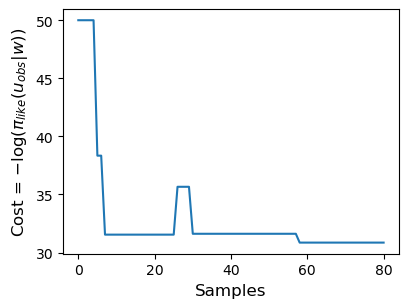

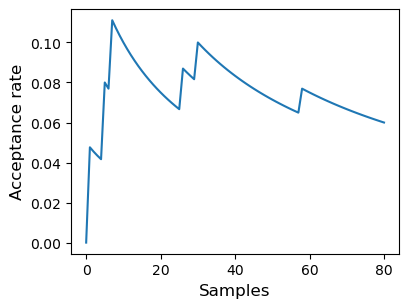

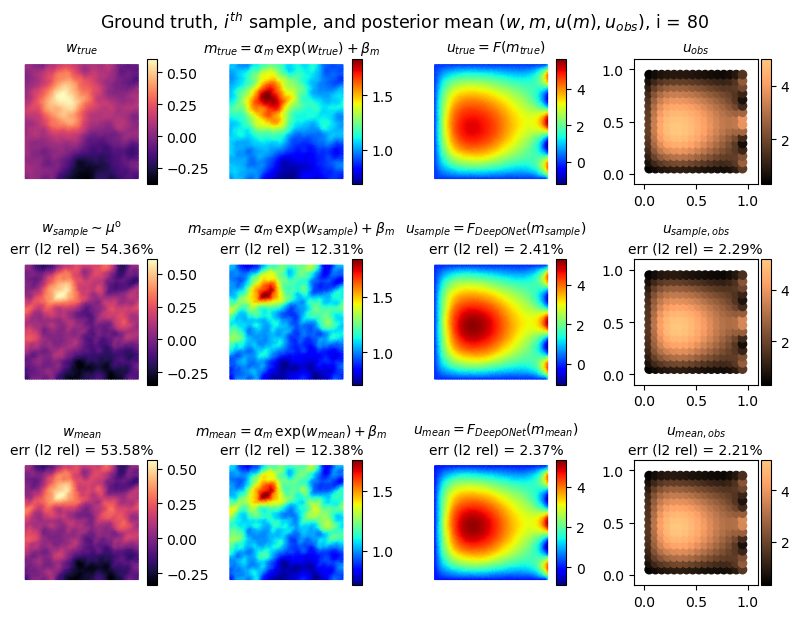

--------------------------------------------------
Sample:  105, Accepted samples:    6, Acceptance Rate: 5.714e-02, Cost mean: 3.286e+01. 
Tracing 5 samples took 4.186e+00s
Error (%) in w: ||w - w_mean|| = 5.343e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.232e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.360e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.203e+00, ||u_obs - u_obs_sample|| = 2.287e+00
--------------------------------------------------
--------------------------------------------------
Sample:  110, Accepted samples:    6, Acceptance Rate: 5.455e-02, Cost mean: 3.286e+01. 
Tracing 5 samples took 2.287e+00s
Error (%) in w: ||w - w_mean|| = 5.343e+01, ||w - w_sample|| = 5.436e+01
Error (%) in m: ||m - m_mean|| = 1.232e+01, ||m - m_sample|| = 1.231e+01
Error (%) in u: ||u - u_mean|| = 2.360e+00, ||u - u_sample|| = 2.413e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.203e+00, ||u_obs - u_ob

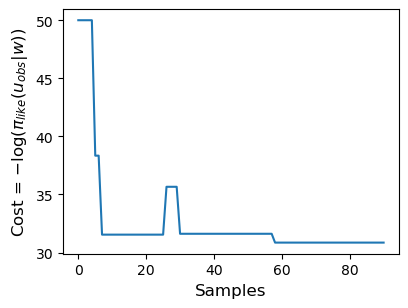

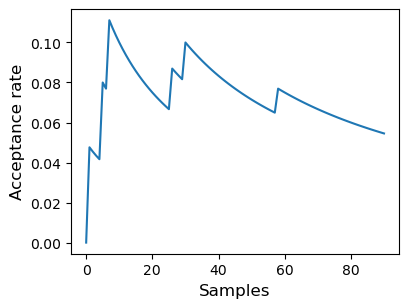

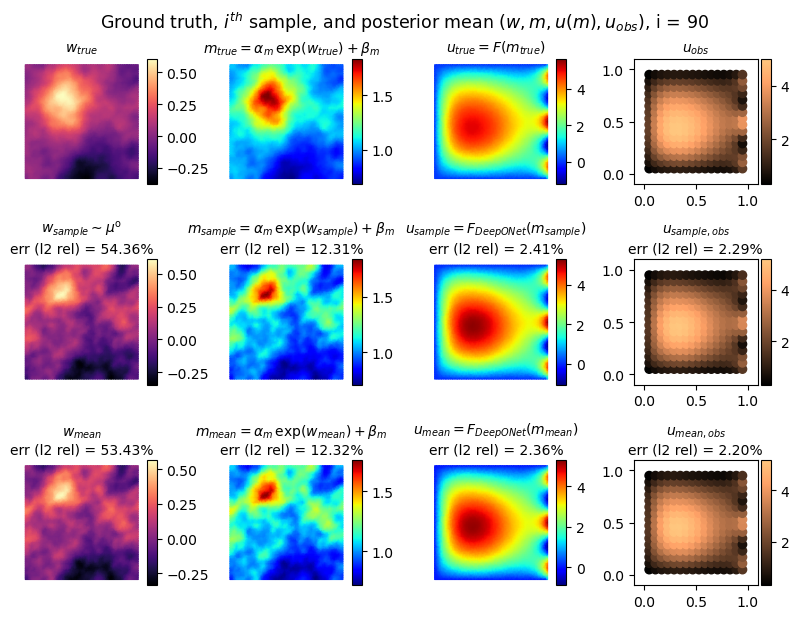

--------------------------------------------------
Sample:  115, Accepted samples:    7, Acceptance Rate: 6.087e-02, Cost mean: 3.263e+01. 
Tracing 5 samples took 4.306e+00s
Error (%) in w: ||w - w_mean|| = 5.332e+01, ||w - w_sample|| = 5.376e+01
Error (%) in m: ||m - m_mean|| = 1.228e+01, ||m - m_sample|| = 1.198e+01
Error (%) in u: ||u - u_mean|| = 2.351e+00, ||u - u_sample|| = 2.434e+00
Error (%) in u_obs: ||u_obs - u_obs_mean|| = 2.199e+00, ||u_obs - u_obs_sample|| = 2.220e+00
--------------------------------------------------
--------------------------------------------------
MCMC finished in 6.307e+01s. 
Total samples:  120, Accepted samples:    7, Acceptance Rate: 5.833e-02, Cost mean: 3.263e+01
--------------------------------------------------


In [ ]:
mcmc.surrogate_to_use = "DeepONet"
mcmc.surrogate_models = surrogate_models

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, f"true_model")

os.makedirs(savepath, exist_ok=True)

run_mcmc = True

if run_mcmc or run_small_test:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=savepath + os.sep,
        init_tracer=True,
    )


## Load tracer and plot

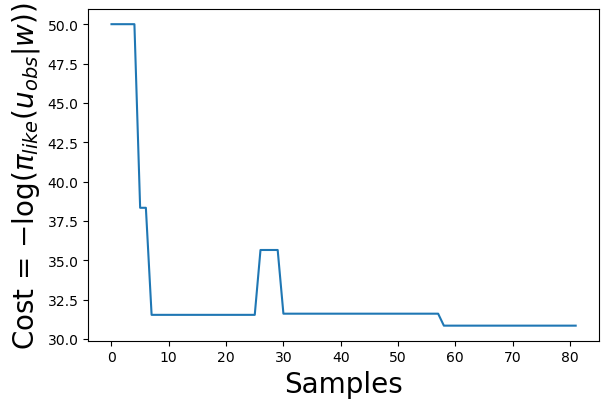

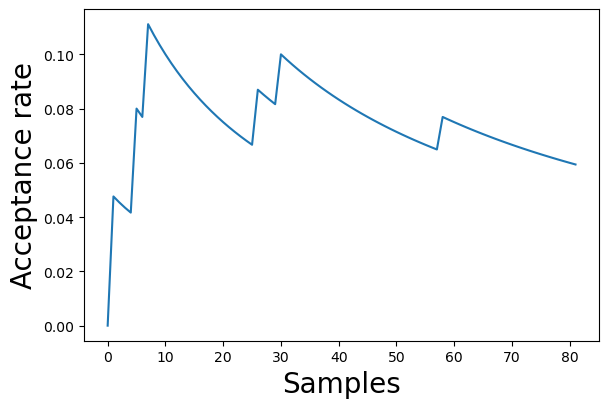

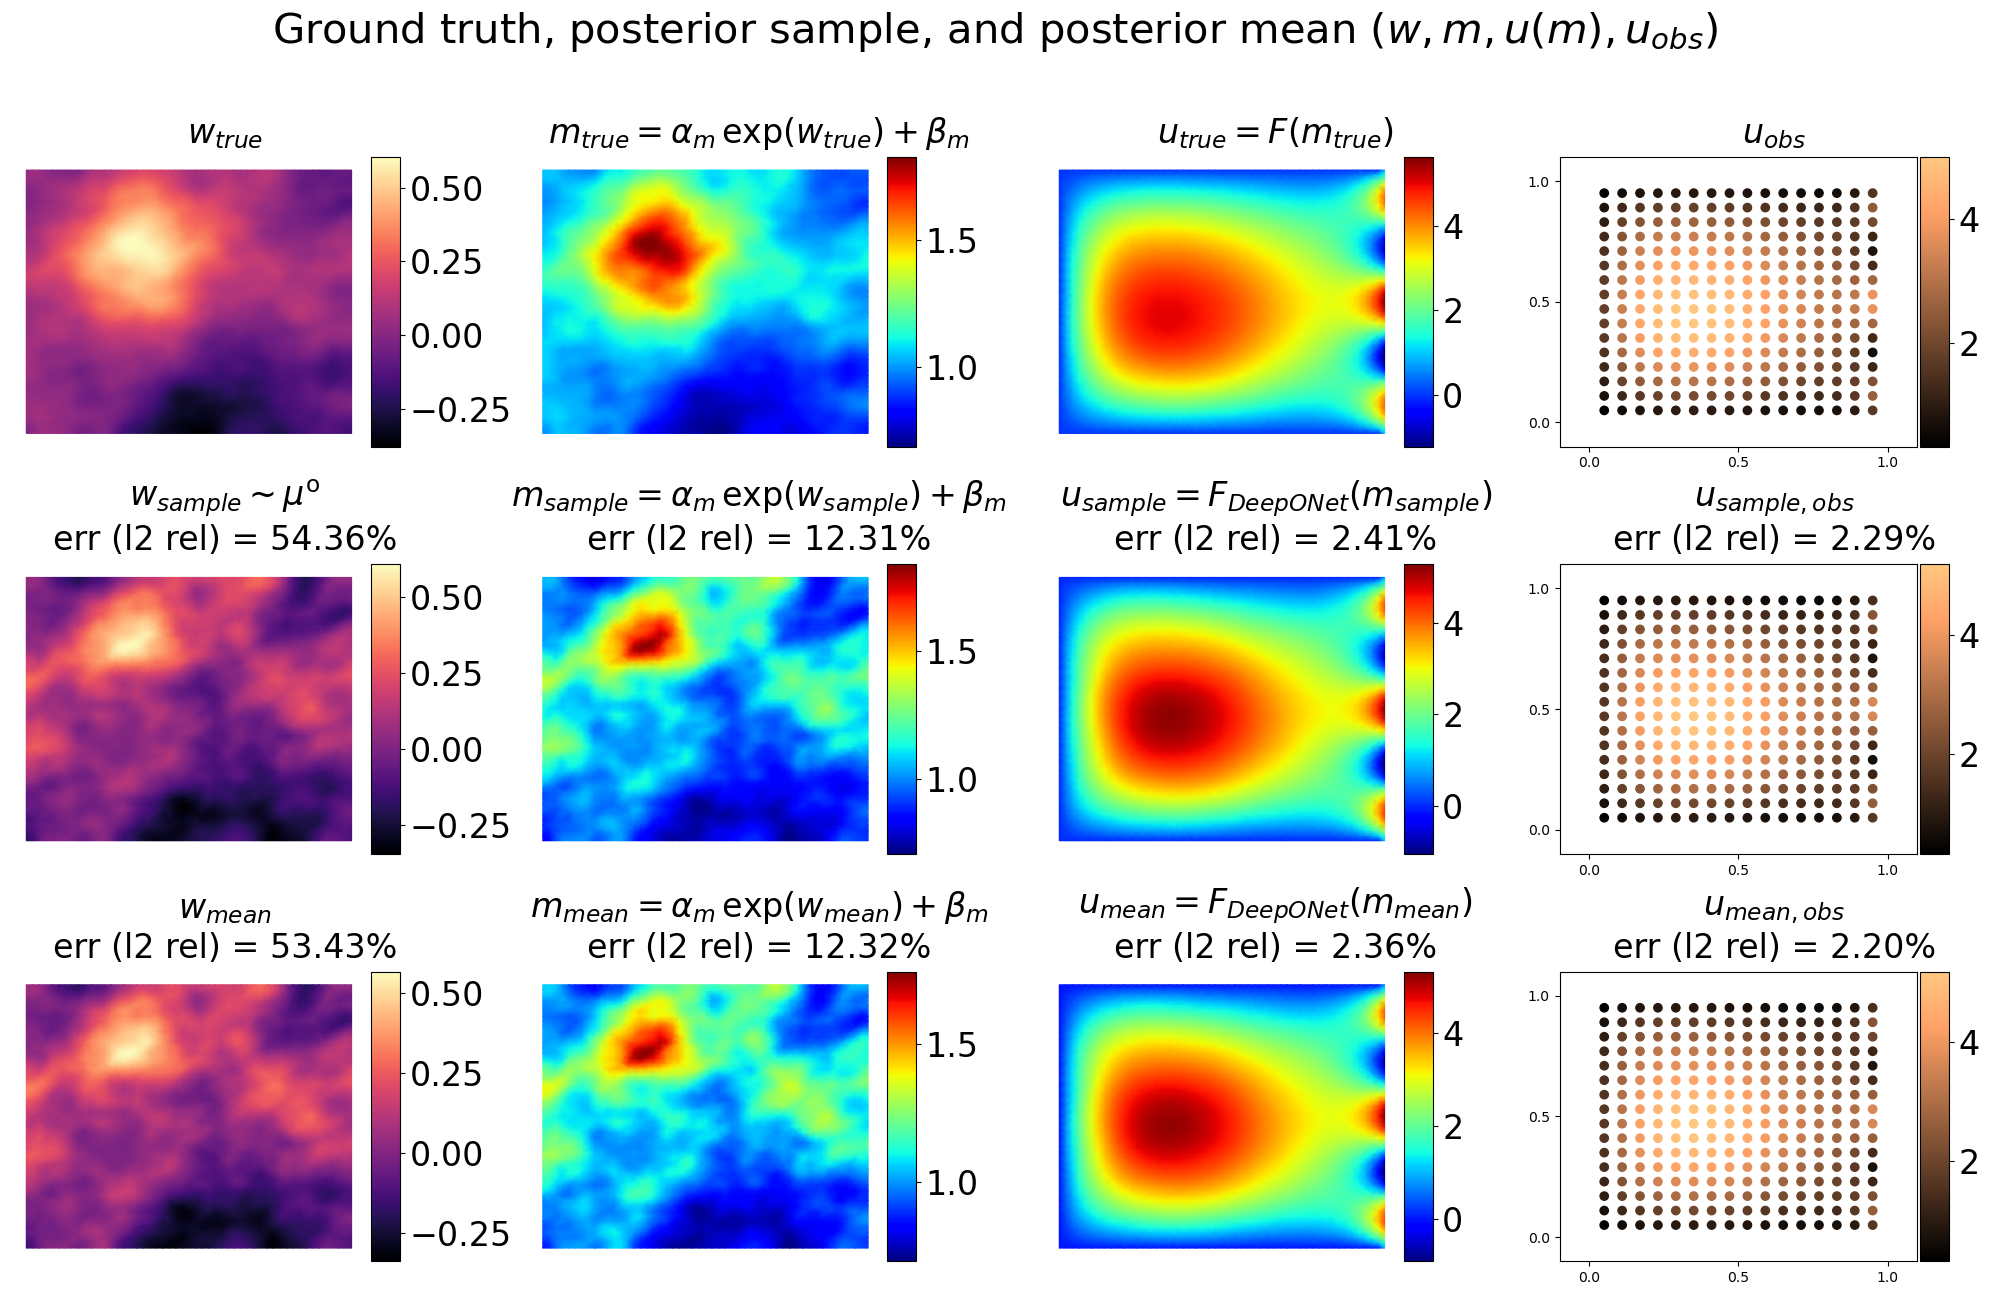

In [ ]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.200_sigma_1.393e-01"
saved_results = savepath

if run_small_test:
        saved_results = savepath

load_tracer = pickle.load(open(saved_results + '/tracer' + '.pkl', 'rb'))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "title_x": [0.6, 0.65, 0.65, 0.6],        
    },
}

pp_params = mcmc_pp_params['curve_plot']
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)


w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)

# MCMC with surrogate: PCANet

In [ ]:
mcmc.surrogate_to_use = "PCANet"
mcmc.surrogate_models = surrogate_models

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = os.path.join(savepath_base, f"true_model")

os.makedirs(savepath, exist_ok=True)

run_mcmc = True
if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=savepath + os.sep,
        init_tracer=True,
    )


## Load tracer and plot

In [ ]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.200_sigma_1.393e-01"
saved_results = savepath

if run_small_test:
        saved_results = savepath

load_tracer = pickle.load(open(saved_results + '/tracer' + '.pkl', 'rb'))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "title_x": [0.6, 0.65, 0.65, 0.6],        
    },
}

pp_params = mcmc_pp_params['curve_plot']
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)


w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)

# MCMC with surrogate: FNO

In [ ]:
mcmc.surrogate_to_use = "FNO"
mcmc.surrogate_models = surrogate_models

if mcmc.surrogate_to_use is not None:
    savepath = os.path.join(savepath_base, f"surrogate_{mcmc.surrogate_to_use}")
else:
    savepath = savepath_base

os.makedirs(savepath, exist_ok=True)

run_mcmc = False
if run_mcmc:
    mcmc.run(
        n_samples=n_samples,
        n_burnin=n_burnin,
        pcn_beta=pcn_beta,
        sigma_noise=sigma_noise,
        print_every=print_every,
        print_lvl=2,
        display_plot_every=display_plot_every,
        savefilename=savefilename,
        savepath=savepath + os.sep,
        init_tracer=True,
    )


## Load tracer and plot

In [ ]:
# saved_results = "processed_results/FINAL_mcmc_results_n_samples_10000_n_burnin_500_pcn_beta_0.200_sigma_1.393e-01"
saved_results = savepath

if run_small_test:
        saved_results = savepath

load_tracer = pickle.load(open(saved_results + '/tracer' + '.pkl', 'rb'))

# adjust plot parameters
mcmc_pp_params = {
    "curve_plot": {"fs": 20, "lw": 3, "figsize": (6, 4)},
    "field_plot": {
        "fs": 24,
        "y_sup_title": 1.075,
        "figsize": (20, 12),
        "ttl_pad": 10,
        "title_x": [0.6, 0.65, 0.65, 0.6],        
    },
}

pp_params = mcmc_pp_params['curve_plot']
plot_curve(
    load_tracer.accepted_samples_cost,
    xl=r"Samples",
    yl=r"Cost = $-\log(\pi_{like}(u_{obs} | w))$",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)
plot_curve(
    load_tracer.acceptance_rate,
    xl=r"Samples",
    yl=r"Acceptance rate",
    fs=pp_params["fs"],
    lw=pp_params["lw"],
    figsize=pp_params["figsize"],
)


w_mean = load_tracer.accepted_samples_mean_m
w_sample_i = len(load_tracer.accepted_samples_m) - 1
w_sample = load_tracer.accepted_samples_m[w_sample_i]

pp_params = mcmc_pp_params["field_plot"]
pp_params["sup_title"] = (
    r"Ground truth, posterior sample, and posterior mean $(w, m, u(m), u_{obs})$"
)
mcmc_plot_fields_base(w_mean, w_sample, w_sample_i, mcmc, savefilename=None, params=pp_params, surrogate_to_use = mcmc.surrogate_to_use)